<a href="https://colab.research.google.com/github/Loopinlogix/LTL_Collection_ML_Project/blob/main/ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##LTL Pallet Collection Success Prediction - ML Learning Final Project - Crystal MacNeil


Predict and LTL pallet collection will be successful and on time based on factors like:
Distance, Weight, number of pallets
Carrier, Route Type, day of week
Weather conditions, traffic and appointment times.

This model is a real world challenge using Binary Classification.

LTL shipping is a $50B+ industry. Failed/delayed collections cost carriers millions in redelivery fees, customer churn, and operational inefficiency. Predicting failures in advance lets dispatchers reroute, reschedule, or notify customers saving money and improving service.

In [35]:
#Github
!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"

!git clone https://github.com/Loopinlogix/LTL_Collection_ML_Project.git
%cd LTL_Collection_ML_Project
!ls


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Cloning into 'LTL_Collection_ML_Project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/LTL_Collection_ML_Project
README.md


Step 1 - Load Dataset

In [26]:

# STEP 1: LOAD THE DATASET

import pandas as pd          # For data tables
import numpy as np           # For math operations
import matplotlib.pyplot as plt   # For basic charts
import seaborn as sns        # For prettier charts
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')  # Hide annoying warnings
import joblib
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully!")

# Load the dataset
df = pd.read_csv('ltl_pallet_collections.csv')


All libraries loaded successfully!


Step 2 - Data Exploration

In [27]:
# STEP 2: EXPLORE THE DATA (EDA - Exploratory Data Analysis)

print("=" * 60)
print("STEP 2: DATA EXPLORATION")
print("=" * 60)

# 2.1 Check data types
print("\n--- 2.1 Data Types ---")
print(df.dtypes)

# 2.2 Check for missing values
print("\n--- 2.2 Missing Values ---")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("\n✅ No missing values found!")
else:
    print(f"\n⚠️ Found {missing.sum()} missing values total")

# 2.3 Basic statistics for numerical columns
print("\n--- 2.3 Numerical Statistics ---")
print(df.describe().round(2))

# 2.4 Check the target variable
print("\n--- 2.4 Target Variable Distribution ---")
target_counts = df['collection_success'].value_counts()
print(f"Failed/Delayed (0): {target_counts[0]} ({target_counts[0]/len(df):.1%})")
print(f"Successful (1):     {target_counts[1]} ({target_counts[1]/len(df):.1%})")

STEP 2: DATA EXPLORATION

--- 2.1 Data Types ---
shipment_id               object
distance_miles           float64
num_pallets                int64
weight_lbs               float64
freight_cost             float64
pickup_window_hours        int64
delivery_window_hours      int64
num_stops                  int64
temperature_f            float64
traffic_index            float64
carrier                   object
route_type                object
pickup_day                object
equipment_type            object
service_level             object
weather                   object
is_hazmat                  int64
appointment_required       int64
liftgate_needed            int64
collection_success         int64
dtype: object

--- 2.2 Missing Values ---
shipment_id              0
distance_miles           0
num_pallets              0
weight_lbs               0
freight_cost             0
pickup_window_hours      0
delivery_window_hours    0
num_stops                0
temperature_f            0
traffi

Step 3 - Visualize the data

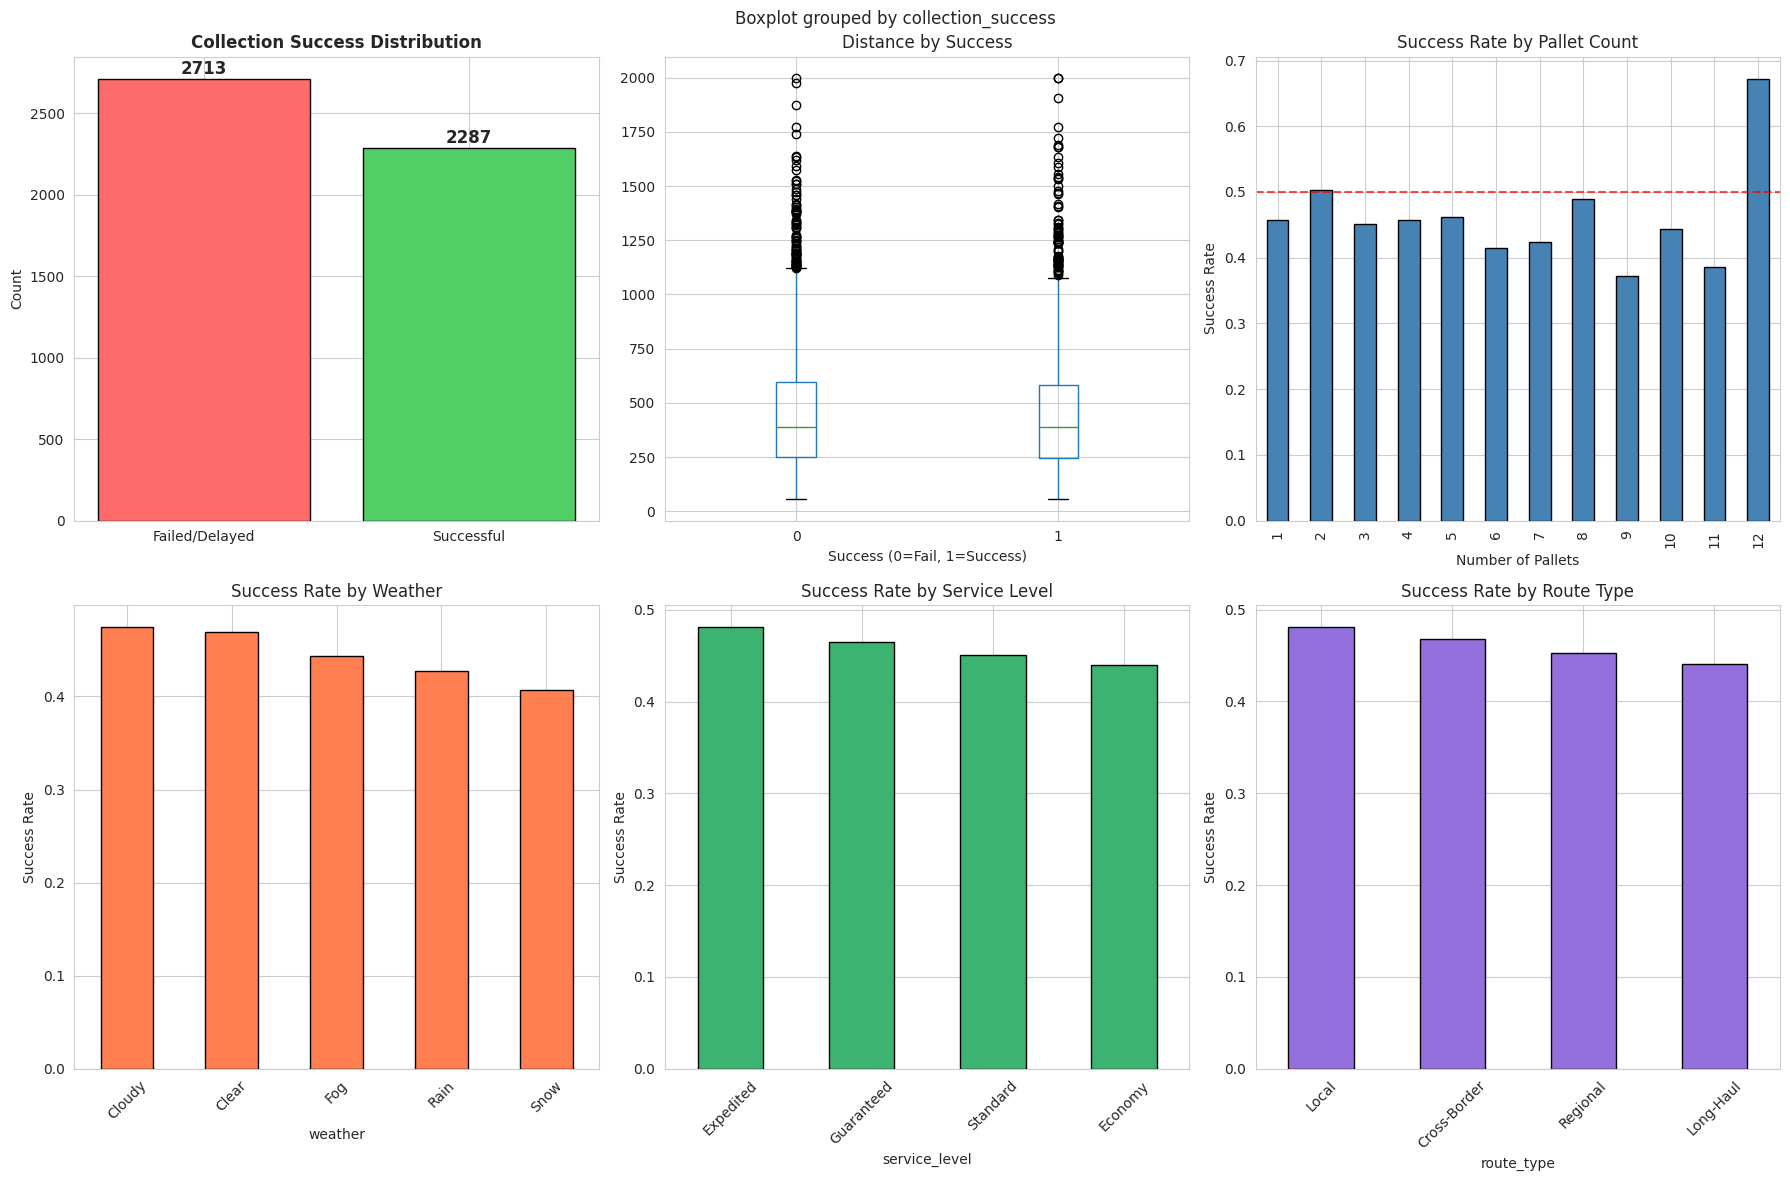

In [15]:
# STEP 4: CREATE VISUALIZATIONS

# Set style
sns.set_style("whitegrid")

# Create a big figure with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('LTL Pallet Collection Data Exploration', fontsize=16, fontweight='bold')

# Plot 1: Success vs Failure count
ax1 = axes[0, 0]
counts = df['collection_success'].value_counts()
bars = ax1.bar(['Failed/Delayed', 'Successful'], counts.values,
               color=['#ff6b6b', '#51cf66'], edgecolor='black')
ax1.set_title('Collection Success Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontweight='bold', fontsize=12)

# Plot 2: Distance distribution by success
ax2 = axes[0, 1]
df.boxplot(column='distance_miles', by='collection_success', ax=ax2)
ax2.set_title('Distance by Success')
ax2.set_xlabel('Success (0=Fail, 1=Success)')

# Plot 3: Success rate by number of pallets
ax3 = axes[0, 2]
pallet_success = df.groupby('num_pallets')['collection_success'].mean()
pallet_success.plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black')
ax3.set_title('Success Rate by Pallet Count')
ax3.set_xlabel('Number of Pallets')
ax3.set_ylabel('Success Rate')
ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.7)

# Plot 4: Weather impact
ax4 = axes[1, 0]
weather_success = df.groupby('weather')['collection_success'].mean().sort_values(ascending=False)
weather_success.plot(kind='bar', ax=ax4, color='coral', edgecolor='black')
ax4.set_title('Success Rate by Weather')
ax4.set_ylabel('Success Rate')
ax4.tick_params(axis='x', rotation=45)

# Plot 5: Service level impact
ax5 = axes[1, 1]
service_success = df.groupby('service_level')['collection_success'].mean().sort_values(ascending=False)
service_success.plot(kind='bar', ax=ax5, color='mediumseagreen', edgecolor='black')
ax5.set_title('Success Rate by Service Level')
ax5.set_ylabel('Success Rate')
ax5.tick_params(axis='x', rotation=45)

# Plot 6: Route type impact
ax6 = axes[1, 2]
route_success = df.groupby('route_type')['collection_success'].mean().sort_values(ascending=False)
route_success.plot(kind='bar', ax=ax6, color='mediumpurple', edgecolor='black')
ax6.set_title('Success Rate by Route Type')
ax6.set_ylabel('Success Rate')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

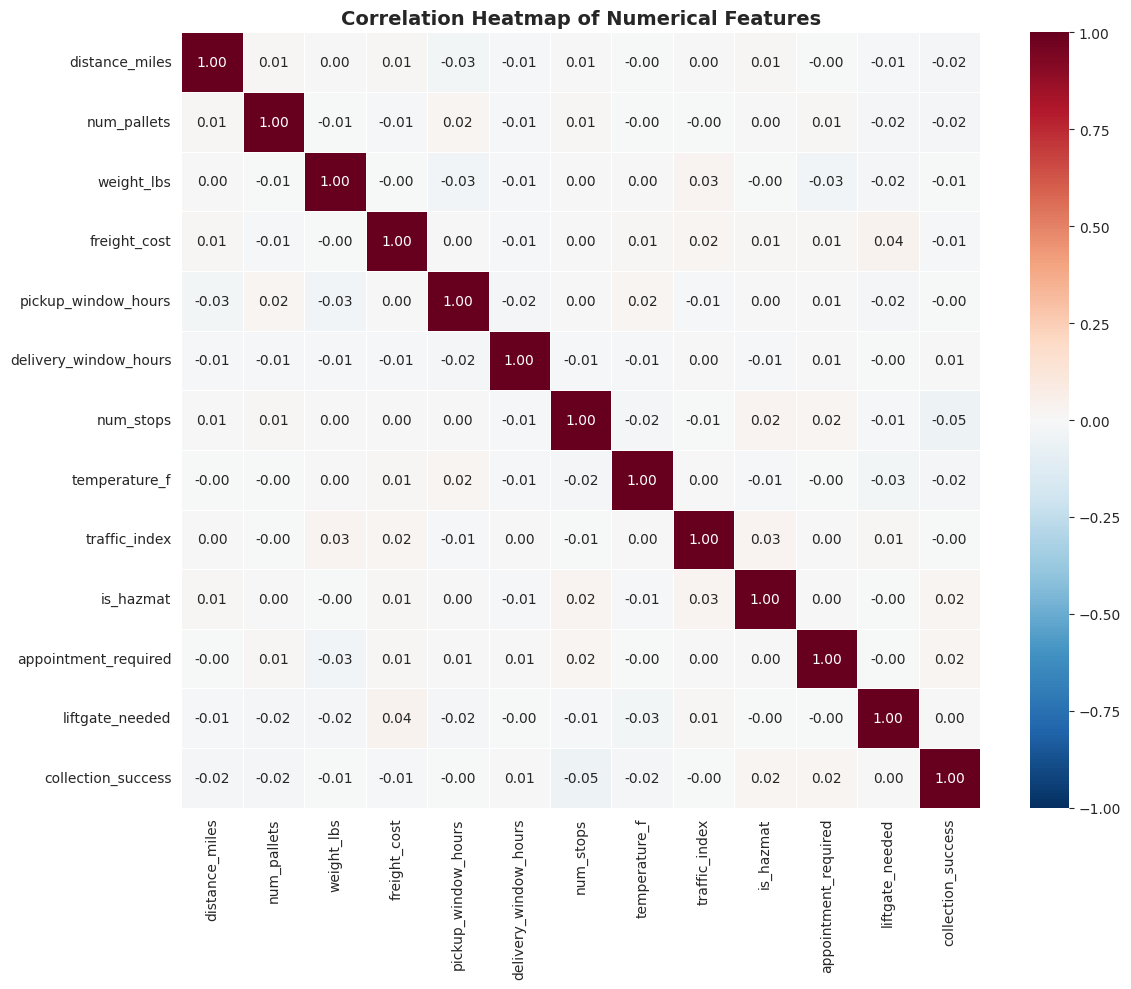

Correlations with collection_success:
num_stops               -0.048764
appointment_required     0.022641
distance_miles          -0.021893
is_hazmat                0.020460
num_pallets             -0.019767
temperature_f           -0.017433
freight_cost            -0.012154
delivery_window_hours    0.007645
weight_lbs              -0.006707
pickup_window_hours     -0.004870
liftgate_needed          0.003754
traffic_index           -0.002377
Name: collection_success, dtype: float64


In [16]:
# STEP 5: CORRELATION ANALYSIS

# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Create correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = numerical_df.corr()

# Draw heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with target
print("Correlations with collection_success:")
target_corr = corr_matrix['collection_success'].drop('collection_success').sort_values(key=abs, ascending=False)
print(target_corr)

In [17]:
# STEP 6: PREPROCESS THE DATA

# 6.1 Make a copy
df_processed = df.copy()

# 6.2 Drop ID column (not useful for prediction)
df_processed = df_processed.drop('shipment_id', axis=1)

# 6.3 Encode categorical variables
# One-hot encoding: turns text categories into 0/1 columns
categorical_cols = ['carrier', 'route_type', 'pickup_day', 'equipment_type',
                    'service_level', 'weather']

print(f"Before encoding: {df_processed.shape[1]} columns")
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
print(f"After encoding: {df_encoded.shape[1]} columns")

# 6.4 Separate features (X) and target (y)
X = df_encoded.drop('collection_success', axis=1)
y = df_encoded['collection_success']

print(f"\nFeatures (X): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} values")

# 6.5 Split into train and test sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training success rate: {y_train.mean():.1%}")
print(f"Test success rate: {y_test.mean():.1%}")

# 6.6 Scale the features (important for some algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete!")

Before encoding: 19 columns
After encoding: 40 columns

Features (X): 5000 rows, 39 columns
Target (y): 5000 values

Training set: 4000 samples
Test set: 1000 samples
Training success rate: 45.8%
Test success rate: 45.7%

Data preprocessing complete!


In [18]:
# STEP 7: TRAIN MACHINE LEARNING MODELS

print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

# MODEL 1: Logistic Regression (simple baseline)
print("\n--- Training Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

# MODEL 2: Random Forest (more powerful)
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=10,           # Prevent overfitting
    min_samples_split=5,    # Minimum samples to split
    random_state=42,
    class_weight='balanced',
    n_jobs=-1             # Use all CPU cores
)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaling
print("Random Forest trained!")

print("\nBoth models ready for evaluation!")

TRAINING MODELS

--- Training Logistic Regression ---
Logistic Regression trained!

--- Training Random Forest ---
Random Forest trained!

Both models ready for evaluation!


In [19]:
# STEP 8: EVALUATE THE MODELS

def evaluate_model(name, y_true, y_pred, y_proba):
    """Calculate all important metrics"""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"Accuracy:  {acc:.4f}  ({acc:.1%})")
    print(f"Precision: {prec:.4f}  ({prec:.1%})")
    print(f"Recall:    {rec:.4f}  ({rec:.1%})")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Fail   Success")
    print(f"Actual  Fail     [{cm[0,0]:4d}]  [{cm[0,1]:4d}]")
    print(f"      Success    [{cm[1,0]:4d}]  [{cm[1,1]:4d}]")

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

# Make predictions
lr_test_pred = lr_model.predict(X_test_scaled)
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate both
lr_metrics = evaluate_model("LOGISTIC REGRESSION", y_test, lr_test_pred, lr_test_proba)
rf_metrics = evaluate_model("RANDOM FOREST", y_test, rf_test_pred, rf_test_proba)

# Compare
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
})
print(comparison.round(4))

# Pick best model
best_model = rf_model if rf_metrics['f1'] > lr_metrics['f1'] else lr_model
best_name = 'Random Forest' if rf_metrics['f1'] > lr_metrics['f1'] else 'Logistic Regression'
print(f"\nBest Model: {best_name}")



  LOGISTIC REGRESSION
Accuracy:  0.4820  (48.2%)
Precision: 0.4412  (44.1%)
Recall:    0.5011  (50.1%)
F1-Score:  0.4693
AUC-ROC:   0.4920

Confusion Matrix:
                 Predicted
                 Fail   Success
Actual  Fail     [ 253]  [ 290]
      Success    [ 228]  [ 229]

  RANDOM FOREST
Accuracy:  0.5050  (50.5%)
Precision: 0.4585  (45.9%)
Recall:    0.4595  (46.0%)
F1-Score:  0.4590
AUC-ROC:   0.5036

Confusion Matrix:
                 Predicted
                 Fail   Success
Actual  Fail     [ 295]  [ 248]
      Success    [ 247]  [ 210]

MODEL COMPARISON
           Logistic Regression  Random Forest
accuracy                0.4820         0.5050
precision               0.4412         0.4585
recall                  0.5011         0.4595
f1                      0.4693         0.4590
auc                     0.4920         0.5036

Best Model: Logistic Regression


In [20]:
# STEP 9: HYPERPARAMETER TUNING
# Try different settings to find the best combination

print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

# Test different Random Forest configurations
configs = [
    {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 10},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
]

best_f1 = 0
best_config = None
best_tuned_model = None

for i, params in enumerate(configs):
    rf = RandomForestClassifier(**params, random_state=42, class_weight='balanced', n_jobs=-1)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    proba = rf.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    print(f"Config {i+1}: trees={params['n_estimators']}, depth={params['max_depth']} -> F1={f1:.4f}, AUC={auc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_config = params
        best_tuned_model = rf

print(f"\nBest configuration: {best_config}")
print(f"Best F1 Score: {best_f1:.4f}")

# Final evaluation of tuned model
final_pred = best_tuned_model.predict(X_test)
final_proba = best_tuned_model.predict_proba(X_test)[:, 1]
final_metrics = evaluate_model("FINAL TUNED MODEL", y_test, final_pred, final_proba)

# Cross-validation
print("\n--- Cross-Validation (5-fold) ---")
cv_scores = cross_val_score(best_tuned_model, X_train, y_train, cv=5, scoring='f1')
print(f"CV F1 Scores: {cv_scores.round(4)}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


HYPERPARAMETER TUNING
Config 1: trees=50, depth=5 -> F1=0.4886, AUC=0.4864
Config 2: trees=100, depth=10 -> F1=0.4590, AUC=0.5036
Config 3: trees=200, depth=15 -> F1=0.4091, AUC=0.5077
Config 4: trees=100, depth=None -> F1=0.3798, AUC=0.5139

Best configuration: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 10}
Best F1 Score: 0.4886

  FINAL TUNED MODEL
Accuracy:  0.5060  (50.6%)
Precision: 0.4637  (46.4%)
Recall:    0.5164  (51.6%)
F1-Score:  0.4886
AUC-ROC:   0.4864

Confusion Matrix:
                 Predicted
                 Fail   Success
Actual  Fail     [ 270]  [ 273]
      Success    [ 221]  [ 236]

--- Cross-Validation (5-fold) ---
CV F1 Scores: [0.4691 0.4895 0.5124 0.5186 0.4888]
Mean CV F1: 0.4957 (+/- 0.0357)


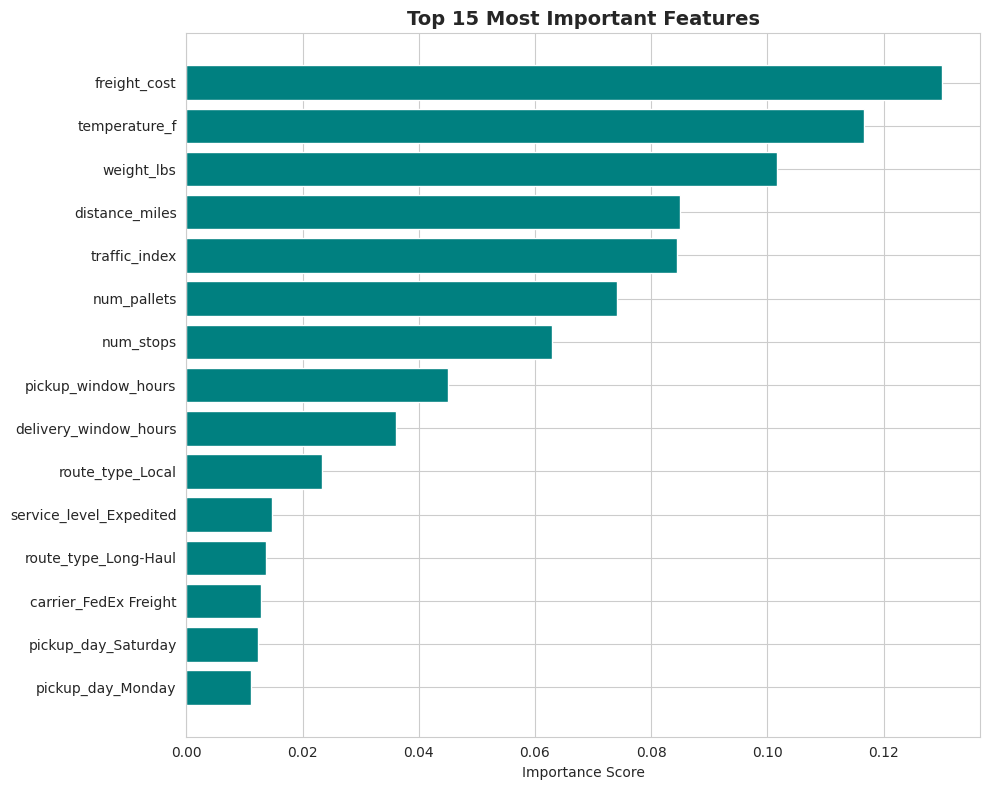

Top 10 Most Important Features:
              Feature  Importance
         freight_cost    0.130093
        temperature_f    0.116694
           weight_lbs    0.101618
       distance_miles    0.084949
        traffic_index    0.084525
          num_pallets    0.074126
            num_stops    0.062872
  pickup_window_hours    0.044996
delivery_window_hours    0.036039
     route_type_Local    0.023394


In [21]:
# STEP 10: FEATURE IMPORTANCE
# Random Forest

# Get feature importances
importances = best_tuned_model.feature_importances_
feature_names = X.columns

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['Importance'], color='teal')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

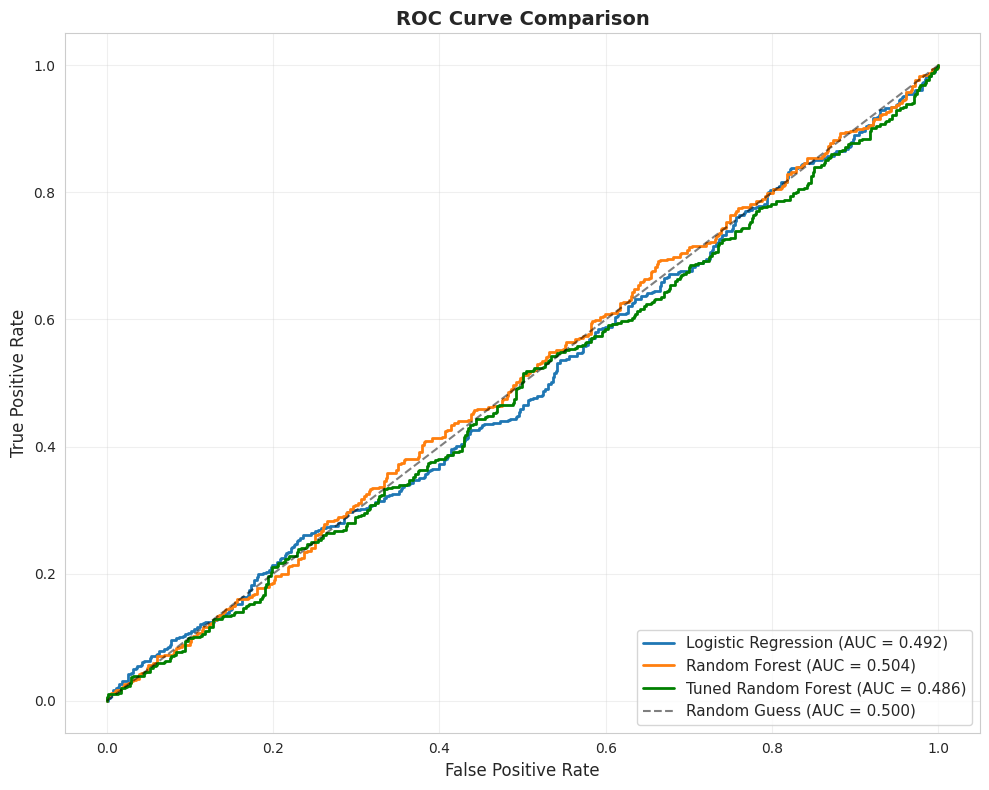

In [22]:
# STEP 11: ROC CURVE COMPARISON

plt.figure(figsize=(10, 8))

# Calculate ROC for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_final, tpr_final, _ = roc_curve(y_test, final_proba)

# Plot each curve
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["auc"]:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_metrics["auc"]:.3f})', linewidth=2)
plt.plot(fpr_final, tpr_final, label=f'Tuned Random Forest (AUC = {final_metrics["auc"]:.3f})', linewidth=2, color='green')

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# STEP 12: INTERACTIVE PREDICTION INTERFACE
# Users can input shipment details and get a prediction

def predict_collection_success():
    """
    Interactive function to predict if an LTL collection will succeed.
    Run this cell, then call: predict_collection_success()
    """
    print("=" * 60)
    print("LTL PALLET COLLECTION SUCCESS PREDICTOR")
    print("=" * 60)
    print("Enter shipment details below:\n")

    # Collect inputs
    distance = float(input("Distance (miles, 50-2000): "))
    pallets = int(input("Number of pallets (1-12): "))
    weight = float(input("Weight (lbs, 500-25000): "))
    cost = float(input("Freight cost ($): "))
    pickup_window = int(input("Pickup window (hours, 2/4/6/8/12/24): "))
    delivery_window = int(input("Delivery window (hours, 2/4/6/8/12/24/48): "))
    stops = int(input("Number of stops (1-5): "))
    temp = float(input("Temperature (°F): "))
    traffic = float(input("Traffic index (0-10): "))

    print("\n--- Categorical Inputs ---")
    carrier = input("Carrier (FedEx Freight/XPO Logistics/Old Dominion/YRC Worldwide/Estes Express/R+L Carriers/SAIA/ABF Freight/Dayton Freight): ")
    route = input("Route type (Local/Regional/Long-Haul/Cross-Border): ")
    day = input("Pickup day (Monday/Tuesday/Wednesday/Thursday/Friday/Saturday/Sunday): ")
    equipment = input("Equipment (Dry Van/Reefer/Flatbed/Step Deck): ")
    service = input("Service level (Standard/Expedited/Guaranteed/Economy): ")
    weather = input("Weather (Clear/Cloudy/Rain/Snow/Fog): ")

    hazmat = int(input("Hazmat? (0=No, 1=Yes): "))
    appointment = int(input("Appointment required? (0=No, 1=Yes): "))
    liftgate = int(input("Liftgate needed? (0=No, 1=Yes): "))

    # Create input DataFrame with same columns as training data
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)

    # Fill numerical values
    input_data['distance_miles'] = distance
    input_data['num_pallets'] = pallets
    input_data['weight_lbs'] = weight
    input_data['freight_cost'] = cost
    input_data['pickup_window_hours'] = pickup_window
    input_data['delivery_window_hours'] = delivery_window
    input_data['num_stops'] = stops
    input_data['temperature_f'] = temp
    input_data['traffic_index'] = traffic
    input_data['is_hazmat'] = hazmat
    input_data['appointment_required'] = appointment
    input_data['liftgate_needed'] = liftgate

    # Fill categorical values (one-hot encoded)
    carrier_col = f'carrier_{carrier}'
    route_col = f'route_type_{route}'
    day_col = f'pickup_day_{day}'
    equip_col = f'equipment_type_{equipment}'
    service_col = f'service_level_{service}'
    weather_col = f'weather_{weather}'

    for col in [carrier_col, route_col, day_col, equip_col, service_col, weather_col]:
        if col in input_data.columns:
            input_data[col] = 1

    # Make prediction
    prediction = best_tuned_model.predict(input_data)[0]
    probability = best_tuned_model.predict_proba(input_data)[0]

    print("\n" + "=" * 60)
    print("PREDICTION RESULT")
    print("=" * 60)
    if prediction == 1:
        print("✅ PREDICTION: Collection will be SUCCESSFUL")
    else:
        print("❌ PREDICTION: Collection will FAIL or be DELAYED")

    print(f"\nConfidence: {probability[prediction]:.1%}")
    print(f"Probability of Success: {probability[1]:.1%}")
    print(f"Probability of Failure: {probability[0]:.1%}")

    # Risk factors
    print("\n--- Risk Factors ---")
    risk_score = 0
    if weather in ['Snow', 'Fog']:
        print(f"⚠️  Adverse weather ({weather}) increases risk")
        risk_score += 1
    if traffic > 5:
        print(f"⚠️  High traffic index ({traffic}) increases risk")
        risk_score += 1
    if stops > 2:
        print(f"⚠️  Multiple stops ({stops}) increase complexity")
        risk_score += 1
    if hazmat == 1:
        print("⚠️  Hazmat shipment requires special handling")
        risk_score += 1
    if route == 'Cross-Border':
        print("⚠️  Cross-border route has customs delays")
        risk_score += 1
    if day in ['Saturday', 'Sunday']:
        print(f"⚠️  Weekend pickup ({day}) has limited resources")
        risk_score += 1

    if risk_score == 0:
        print("✓ No major risk factors identified")




In [32]:
# STEP 13: SAVE MODEL AND PROCESSED DATA

import joblib

# Save the trained model
joblib.dump(best_tuned_model, 'ltl_success_model.pkl')
print("Model saved as 'ltl_success_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

# Save feature names
pd.Series(X.columns).to_csv('feature_names.csv', index=False)
print("Feature names saved as 'feature_names.csv'")

# Save processed dataset
df_encoded.to_csv('ltl_processed.csv', index=False)
print("Processed dataset saved as 'ltl_processed.csv'")

print("\nAll files ready for deployment!")

Model saved as 'ltl_success_model.pkl'
Scaler saved as 'scaler.pkl'
Feature names saved as 'feature_names.csv'
Processed dataset saved as 'ltl_processed.csv'

All files ready for deployment!


In [33]:
predict_collection_success()

LTL PALLET COLLECTION SUCCESS PREDICTOR
Enter shipment details below:

Distance (miles, 50-2000): 100
Number of pallets (1-12): 1
Weight (lbs, 500-25000): 2000
Freight cost ($): 1500
Pickup window (hours, 2/4/6/8/12/24): 6
Delivery window (hours, 2/4/6/8/12/24/48): 24
Number of stops (1-5): 2
Temperature (°F): 15
Traffic index (0-10): 02

--- Categorical Inputs ---
Carrier (FedEx Freight/XPO Logistics/Old Dominion/YRC Worldwide/Estes Express/R+L Carriers/SAIA/ABF Freight/Dayton Freight): Dayton Freight
Route type (Local/Regional/Long-Haul/Cross-Border): Long-Haul
Pickup day (Monday/Tuesday/Wednesday/Thursday/Friday/Saturday/Sunday): Monday
Equipment (Dry Van/Reefer/Flatbed/Step Deck): Flatbed
Service level (Standard/Expedited/Guaranteed/Economy): Economy
Weather (Clear/Cloudy/Rain/Snow/Fog): Fog
Hazmat? (0=No, 1=Yes): 1
Appointment required? (0=No, 1=Yes): 0
Liftgate needed? (0=No, 1=Yes): 1

PREDICTION RESULT
✅ PREDICTION: Collection will be SUCCESSFUL

Confidence: 52.3%
Probability o